In [42]:
import sys
import csv
import os
import regex as re
import numpy as np

# /workspaces/collaborative-scene-graphs/metrics/2025-02-19T14:35-OG-completed
# /workspaces/collaborative-scene-graphs/metrics/2025-02-19T19:50-MaskCLIP-completed
# /workspaces/collaborative-scene-graphs/metrics/2025-02-19T23:58
eval_sessions = """
/workspaces/collaborative-scene-graphs/metrics/2025-02-26T19:47-final1
/workspaces/collaborative-scene-graphs/metrics/2025-02-27T11:30-final2
/workspaces/collaborative-scene-graphs/metrics/2025-02-28T00:16-final3
""".strip().split(
    "\n"
)

use_se2 = True

eval_runs = []
n_sessions = len(eval_sessions)
seqs = []
for session in eval_sessions:
    runs = os.listdir(session)
    for run in runs:
        match = re.match(r"agents-(\d+)_remove_dyn_objs-(True|False)", run)
        if match is None:
            print(f"skipping {run}")
            continue
        agents, rdo = match.groups()

        seq = {}
        seq["remove_dyn"] = rdo == "True"
        seq["n_agents"] = len(agents)
        seq["run"] = run
        seq["session"] = session
        d = os.path.join(session, run)
        ate_fname = "se2_ate.csv" if use_se2 else "ate.csv"
        with open(d + "/" + ate_fname, "r") as f:
            reader = csv.DictReader(f)
            seq["ate_metrics"] = list(reader)
            # read floats
            seq["ate_metrics"] = [
                {k: float(v) for k, v in m.items()} for m in seq["ate_metrics"]
            ]
            seq["ate_metrics"].sort(key=lambda x: x["timestamp"])
            if len(seq["ate_metrics"]) < 10:
                print(f"skipping {run} due to insufficient ate data")
                continue

        kitti_fname = "se2_kitti.csv" if use_se2 else "kitti.csv"
        with open(d + "/" + kitti_fname, "r") as f:
            reader = csv.DictReader(f)
            seq["kitti_metrics"] = list(reader)
            # read floats
            seq["kitti_metrics"] = [
                {k: float(v) for k, v in m.items()} for m in seq["kitti_metrics"]
            ]
            seq["kitti_metrics"].sort(key=lambda x: x["timestamp"])
            if len(seq["kitti_metrics"]) < 10:
                print(f"skipping {run} due to insufficient kitti data")
                continue
            seqs.append(seq)


print([len(seq["ate_metrics"]) for seq in seqs])
print([len(seq["kitti_metrics"]) for seq in seqs])
print(seqs[1]["kitti_metrics"])
print(np.array([m["timestamp"] for m in seqs[1]["ate_metrics"]])[:3])
np.array([m["timestamp"] for m in seqs[1]["kitti_metrics"]])[:3]

[210, 206, 341, 205, 335, 505, 333, 191, 210, 507, 341, 192, 343, 335, 210, 206, 341, 205, 341, 505, 333, 191, 210, 507, 341, 192, 343, 335, 210, 206, 341, 205, 341, 505, 333, 199, 210, 507, 341, 192, 343, 335]
[210, 206, 341, 205, 335, 505, 333, 191, 210, 507, 341, 192, 343, 335, 210, 206, 341, 205, 341, 505, 333, 191, 210, 507, 341, 192, 343, 335, 210, 206, 341, 205, 341, 505, 333, 199, 210, 507, 341, 192, 343, 335]
[{'timestamp': 9.831286191, 'mean_transl_err': nan, 'std_transl_err': nan, 'mean_rot_err': nan, 'std_rot_err': nan}, {'timestamp': 19.831537961, 'mean_transl_err': nan, 'std_transl_err': nan, 'mean_rot_err': nan, 'std_rot_err': nan}, {'timestamp': 29.831174135, 'mean_transl_err': nan, 'std_transl_err': nan, 'mean_rot_err': nan, 'std_rot_err': nan}, {'timestamp': 39.831751108, 'mean_transl_err': 1.9253273762697345, 'std_transl_err': 0.07850971350701781, 'mean_rot_err': 0.0023198947094546928, 'std_rot_err': 0.0007463682908865321}, {'timestamp': 49.831474781, 'mean_transl_er

array([ 9.83128619, 19.83153796, 29.83117414])

In [43]:
# find the earliest end stamp
end_stamp = min([float(seq["ate_metrics"][-1]["timestamp"]) for seq in seqs if len(seq["ate_metrics"]) > 0])

# cut each sequence to end at the end_stamp
for seq in seqs:
    seq["ate_metrics"] = list(filter(lambda x: float(x["timestamp"]) <= end_stamp, seq["ate_metrics"]))


In [44]:
x = np.linspace(0, end_stamp, 1000)

# interpolate to same timestamps
all_interp_keys = set()
for seq in seqs:
    seq["timestamps_interp"] = x
    xp = np.array([m["timestamp"] for m in seq["ate_metrics"]])
    for metric_name in ["mean_ate", "std_ate"]:
        fp = np.array([m[metric_name] for m in seq["ate_metrics"]])
        ate_interp = np.interp(x, xp, fp)
        seq[metric_name + "_interp"] = ate_interp
        all_interp_keys.add(metric_name + "_interp")
    xp = np.array([m["timestamp"] for m in seq["kitti_metrics"]])
    for metric_name in ["mean_transl_err", "mean_rot_err", "std_transl_err", "std_rot_err"]:
        fp = np.array([m[metric_name] for m in seq["kitti_metrics"]])
        ate_interp = np.interp(x, xp, fp)
        seq[metric_name + "_interp"] = ate_interp
        all_interp_keys.add(metric_name + "_interp")


In [45]:
import pickle
pickle.dump(seqs, open(f"{eval_sessions[-1]}-data.pkl", "wb"))

In [46]:

for seq in seqs:
    if seq['n_agents'] == 1:
        continue
    grad = np.gradient(seq["mean_ate_interp"])
    # find the first index where the gradient is below threshold
    idx = np.argmax(grad < -40) + 20
    for key in all_interp_keys:
        seq[key][:idx] = np.nan
    
    if seq['n_agents']:
        grad = np.gradient(seq["mean_ate_interp"])
        # find the first index where the gradient is below threshold
        idx = np.argmax(grad < -40) + 20
        for key in all_interp_keys:
            seq[key][:idx] = np.nan

In [47]:
max_n_agents = max([seq["n_agents"] for seq in seqs])
x_len = seqs[0]["timestamps_interp"].shape[0]
n_metrics = len(all_interp_keys)

metrics_by_rdo_by_n = np.zeros((max_n_agents, 2, n_metrics, x_len))
for n_agents in range(max_n_agents):
    seqs_n_agents = list(filter(lambda x: x["n_agents"] == n_agents + 1, seqs))
    for rdo in [True, False]:
        seqs_n_agents_rdo = list(filter(lambda x: x["remove_dyn"] == rdo, seqs_n_agents))
        if len(seqs_n_agents_rdo) == 0:
            print(f"no data for {n_agents + 1} agents, remove_dyn={rdo}")
            continue
        for i, seq in enumerate(seqs_n_agents_rdo):
            metrics_by_rdo_by_n[n_agents, int(rdo), 0] += seq['mean_ate_interp']
            metrics_by_rdo_by_n[n_agents, int(rdo), 1] += seq['std_ate_interp']
            metrics_by_rdo_by_n[n_agents, int(rdo), 2] += seq['mean_transl_err_interp']
            metrics_by_rdo_by_n[n_agents, int(rdo), 3] += seq['std_transl_err_interp']
            metrics_by_rdo_by_n[n_agents, int(rdo), 4] += seq['mean_rot_err_interp']
            metrics_by_rdo_by_n[n_agents, int(rdo), 5] += seq['std_rot_err_interp']
        metrics_by_rdo_by_n[n_agents, int(rdo)] /= len(seqs_n_agents_rdo)
        

In [68]:
rdo_sel = False

spread_by_n_agents = [[], [], []]
for seq in seqs:
    if seq["remove_dyn"] != rdo_sel:
        continue
    y = seq["mean_ate_interp"]
    spread_by_n_agents[seq["n_agents"] - 1].append(y)
    
spread_by_n_agents = [np.vstack([a]).std(axis=0) for a in spread_by_n_agents]

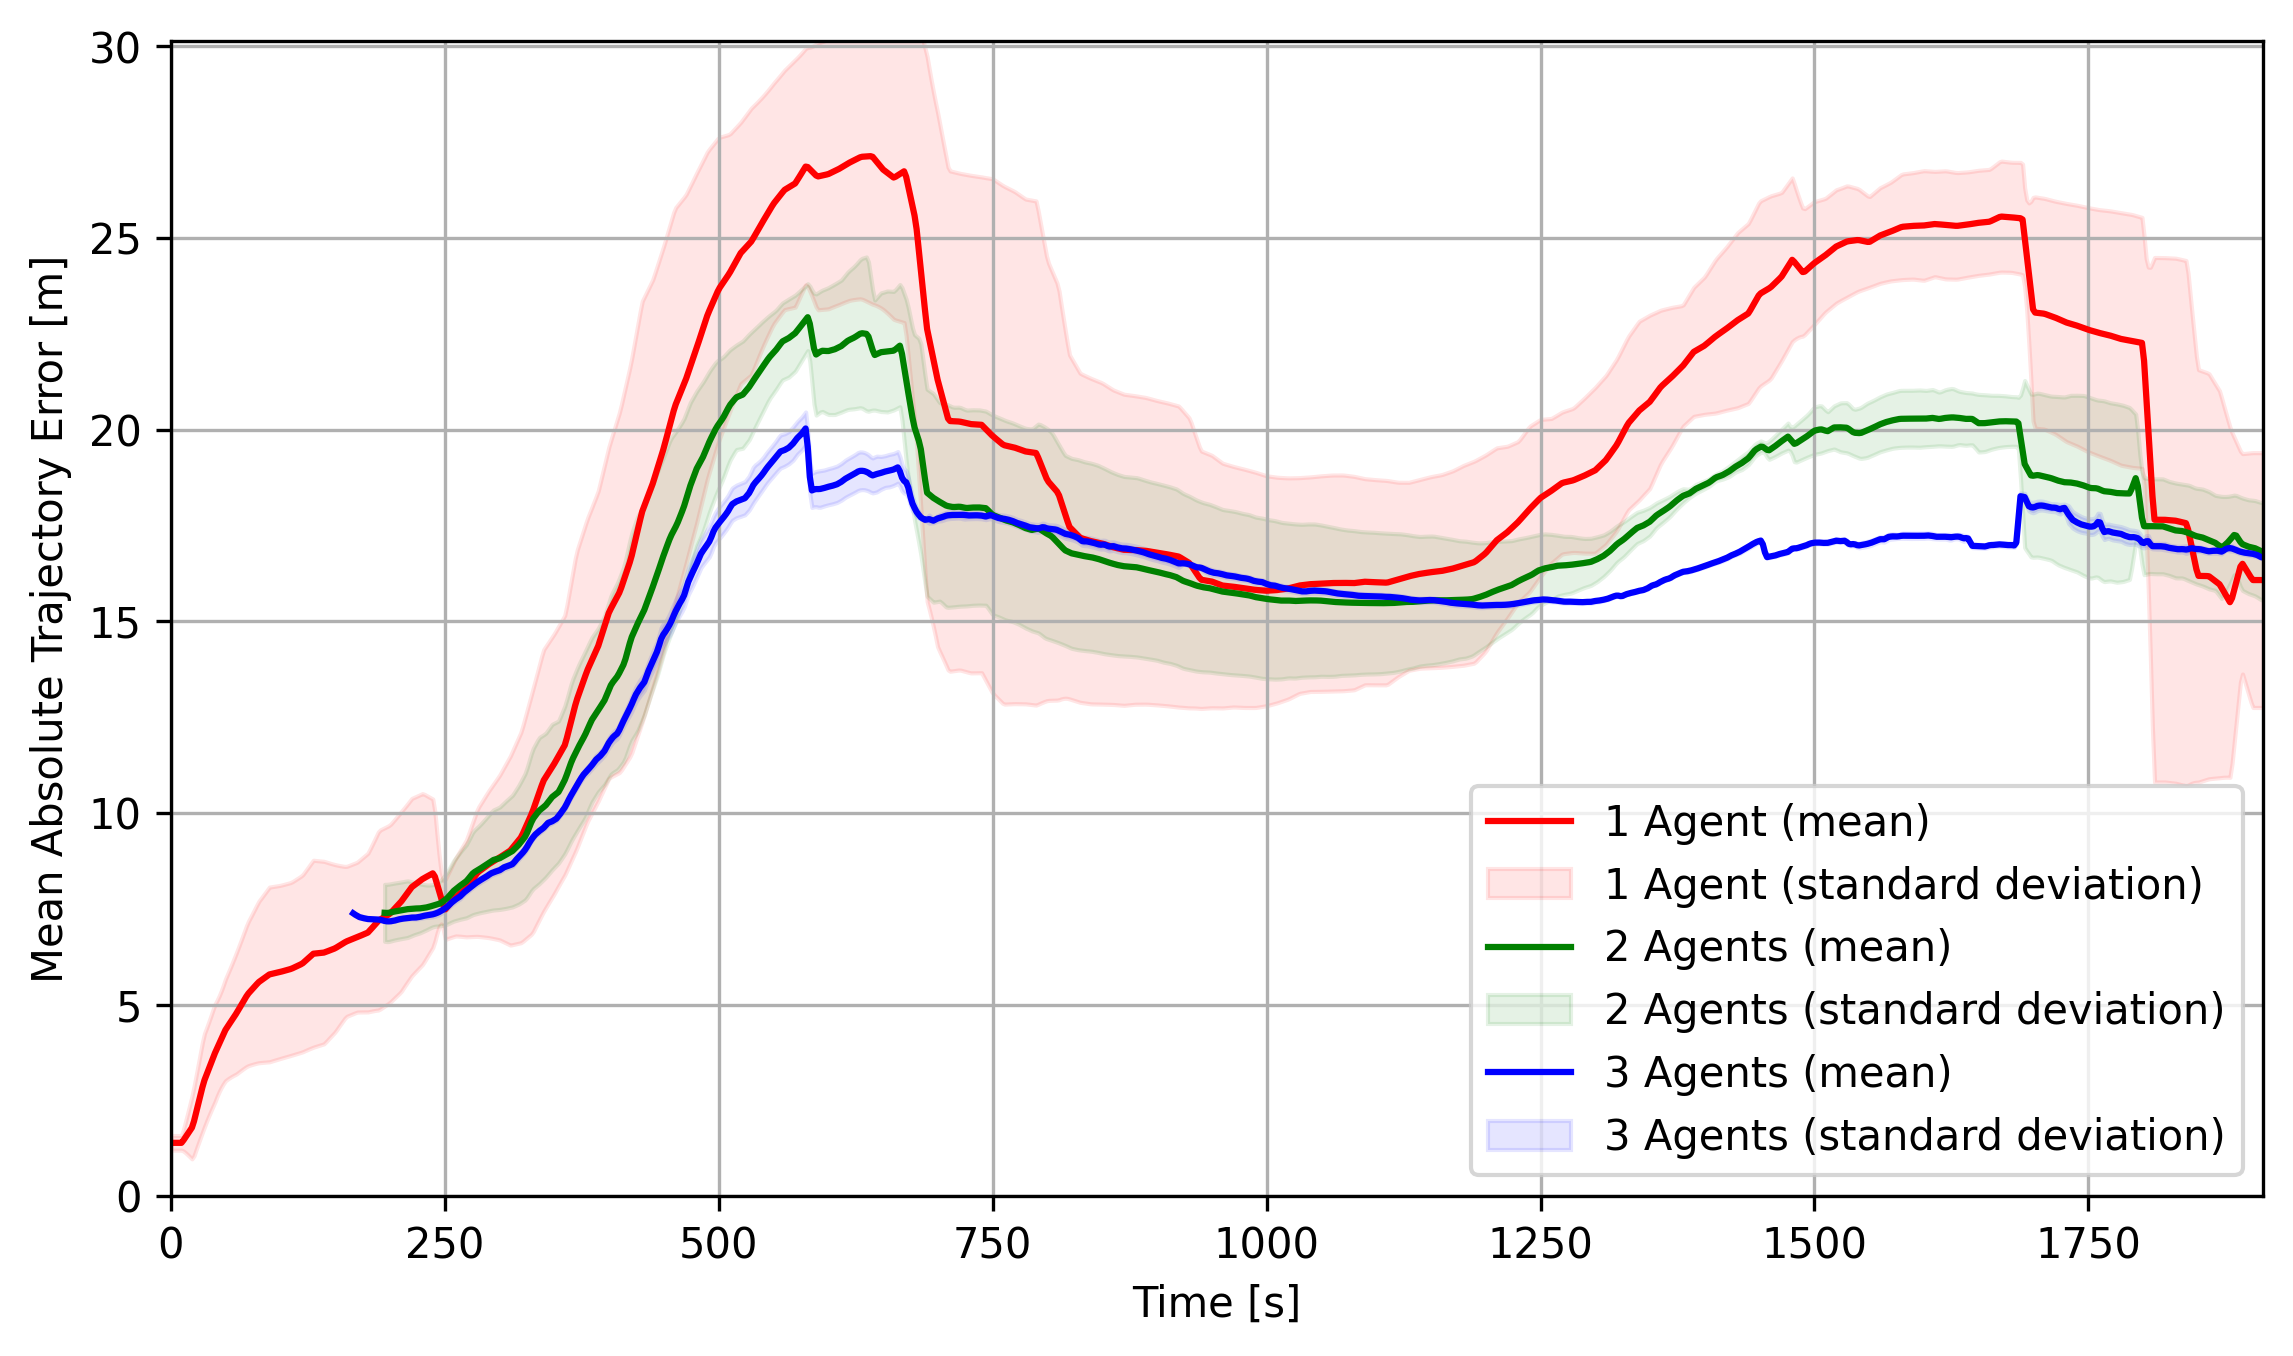

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.rcParams['figure.dpi'] = 300

colors = ['red', 'green', 'blue']

rdo_sel = False

for n_agents in range(max_n_agents):
    y = metrics_by_rdo_by_n[n_agents, int(rdo_sel), 0]
    # plt.plot(x, y, label=f'{n_agents + 1} agents', color=colors[n_agents], linestyle='solid', linewidth=1.5, alpha=1.0)
    plt.fill_between(x, y - spread_by_n_agents[n_agents], y + spread_by_n_agents[n_agents], color=colors[n_agents], alpha=0.1)


max_y = 0
for n_agents in range(max_n_agents):
    y = metrics_by_rdo_by_n[n_agents, int(rdo_sel), 0]
    max_y = max(max_y, max(y))
    plt.plot(x, y, label=f'{n_agents + 1} agents', color=colors[n_agents], linestyle='solid', linewidth=1.5, alpha=1.0)
    
plt.xlabel('Time [s]')
plt.ylabel('Mean Absolute Trajectory Error [m]')
# cut negative values
plt.ylim(bottom=0)
# plt.ylim(top=max(max(mate_0), max(mate_1), max(mate_2)) + 10)
plt.ylim(top=max_y + 3)
plt.xlim(left=0)
plt.xlim(right=end_stamp)
# plt.title('Mean Absolute Trajectory Error with SE(2) GT')

import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# label = '(dyn. points removed)' if rdo_sel else '(dyn. points not removed)'
label = ''
handles = [
    mlines.Line2D([], [], color='red', linestyle='solid', label='1 Agent (mean)' + label),
    mpatches.Patch(color='red', alpha=0.1, label='1 Agent (standard deviation)'),

    mlines.Line2D([], [], color='green', linestyle='solid', label='2 Agents (mean)' + label),
    mpatches.Patch(color='green', alpha=0.1, label='2 Agents (standard deviation)'),

    mlines.Line2D([], [], color='blue', linestyle='solid', label='3 Agents (mean)' + label),
    mpatches.Patch(color='blue', alpha=0.1, label='3 Agents (standard deviation)'),
]
plt.legend(handles=handles, loc="best")

plt.grid()

plt.savefig(f"{eval_sessions[-1]}-ate{int(rdo_sel)}.pdf", bbox_inches='tight', pad_inches=0.1, dpi=300, format='pdf', transparent=True)

plt.show()


In [49]:
#                                                                ATE        E_trans     E_rot
mean_metrics_by_rdo_by_n = np.nanmean(metrics_by_rdo_by_n, axis=3)
mean_metrics_by_rdo_by_n[:, :, 4:6] *= 1000
s = [
    "\\multirow{2}{*}{\\textbf{1 Agent}}  & \\xmark & " + "\\({:.1f}\\pm{:.1f}\\) & \\({:.1f}\\pm{:.1f}\\) & \\({:.1f}\\pm{:.1f}\\) \\\\".format(*mean_metrics_by_rdo_by_n[0,0]),
    "                                   & \\cmark & " +   "\\({:.1f}\\pm{:.1f}\\) & \\({:.1f}\\pm{:.1f}\\) & \\({:.1f}\\pm{:.1f}\\) \\\\".format(*mean_metrics_by_rdo_by_n[0,1]),
    "\\multirow{2}{*}{\\textbf{2 Agents}} & \\xmark & " + "\\({:.1f}\\pm{:.1f}\\) & \\({:.1f}\\pm{:.1f}\\) & \\({:.1f}\\pm{:.1f}\\) \\\\".format(*mean_metrics_by_rdo_by_n[1,0]),
    "                                   & \\cmark & " +   "\\({:.1f}\\pm{:.1f}\\) & \\({:.1f}\\pm{:.1f}\\) & \\({:.1f}\\pm{:.1f}\\) \\\\".format(*mean_metrics_by_rdo_by_n[1,1]),
    "\\multirow{2}{*}{\\textbf{3 Agents}} & \\xmark & " + "\\({:.1f}\\pm{:.1f}\\) & \\({:.1f}\\pm{:.1f}\\) & \\({:.1f}\\pm{:.1f}\\) \\\\".format(*mean_metrics_by_rdo_by_n[2,0]),
    "                                   & \\cmark & " +   "\\({:.1f}\\pm{:.1f}\\) & \\({:.1f}\\pm{:.1f}\\) & \\({:.1f}\\pm{:.1f}\\) \\\\".format(*mean_metrics_by_rdo_by_n[2,1]),
]
print("\n".join(s))

\multirow{2}{*}{\textbf{1 Agent}}  & \xmark & \(17.8\pm11.6\) & \(2.2\pm2.8\) & \(7.7\pm13.4\) \\
                                   & \cmark & \(21.7\pm14.9\) & \(2.3\pm2.8\) & \(7.5\pm12.6\) \\
\multirow{2}{*}{\textbf{2 Agents}} & \xmark & \(17.0\pm11.4\) & \(2.0\pm2.6\) & \(6.8\pm12.1\) \\
                                   & \cmark & \(17.4\pm11.9\) & \(2.1\pm2.6\) & \(6.8\pm11.9\) \\
\multirow{2}{*}{\textbf{3 Agents}} & \xmark & \(15.7\pm10.2\) & \(1.1\pm1.0\) & \(3.4\pm4.7\) \\
                                   & \cmark & \(17.3\pm11.3\) & \(2.2\pm2.5\) & \(7.1\pm11.6\) \\
